# Description

Welcome to the 2025 Kaggle Playground Series! We plan to continue in the spirit of previous playgrounds, providing interesting and approachable datasets for our community to practice their machine learning skills, and anticipate a competition each month.

Your Goal: Your goal is to predict whether a client will subscribe to a bank term deposit.

In [1]:
# Import helpful libraries
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import roc_auc_score

## Data upload

In [2]:
df = pd.read_csv(r"C:\Users\paul_\OneDrive\Documentos\Python Scripts\binary_classification_with_a_bank_dataset/train.csv")

df_test = pd.read_csv(r"C:\Users\paul_\OneDrive\Documentos\Python Scripts\binary_classification_with_a_bank_dataset/test.csv")

## Data preparation

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [4]:
# General description of the data
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,216506.495284,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,0.000000,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,187499.750000,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,374999.500000,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,562499.250000,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,749999.000000,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [5]:
# Let's see the first rows of the data
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [6]:
# Select numerical and categorical column names
num_col = [c for c in df.columns if df[c].dtype in ['int64', 'float64']]
cat_col = df.select_dtypes(include='object').columns

print("Numerical columns: ", num_col)
print("Categorical columns: ", cat_col)

Numerical columns:  ['id', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y']
Categorical columns:  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


* The dataset contains 750k observations and 18 columns.
* There's a mix between **numerical(int64)** and **categorical(object)** colums:
    - **Numerical columns:** ['id', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y']
    - **Categorical columns:** ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
* There are no missing values
* Target is columns **y** which is binary (0 or 1)

## Exploratory Data Analysis (EDA)

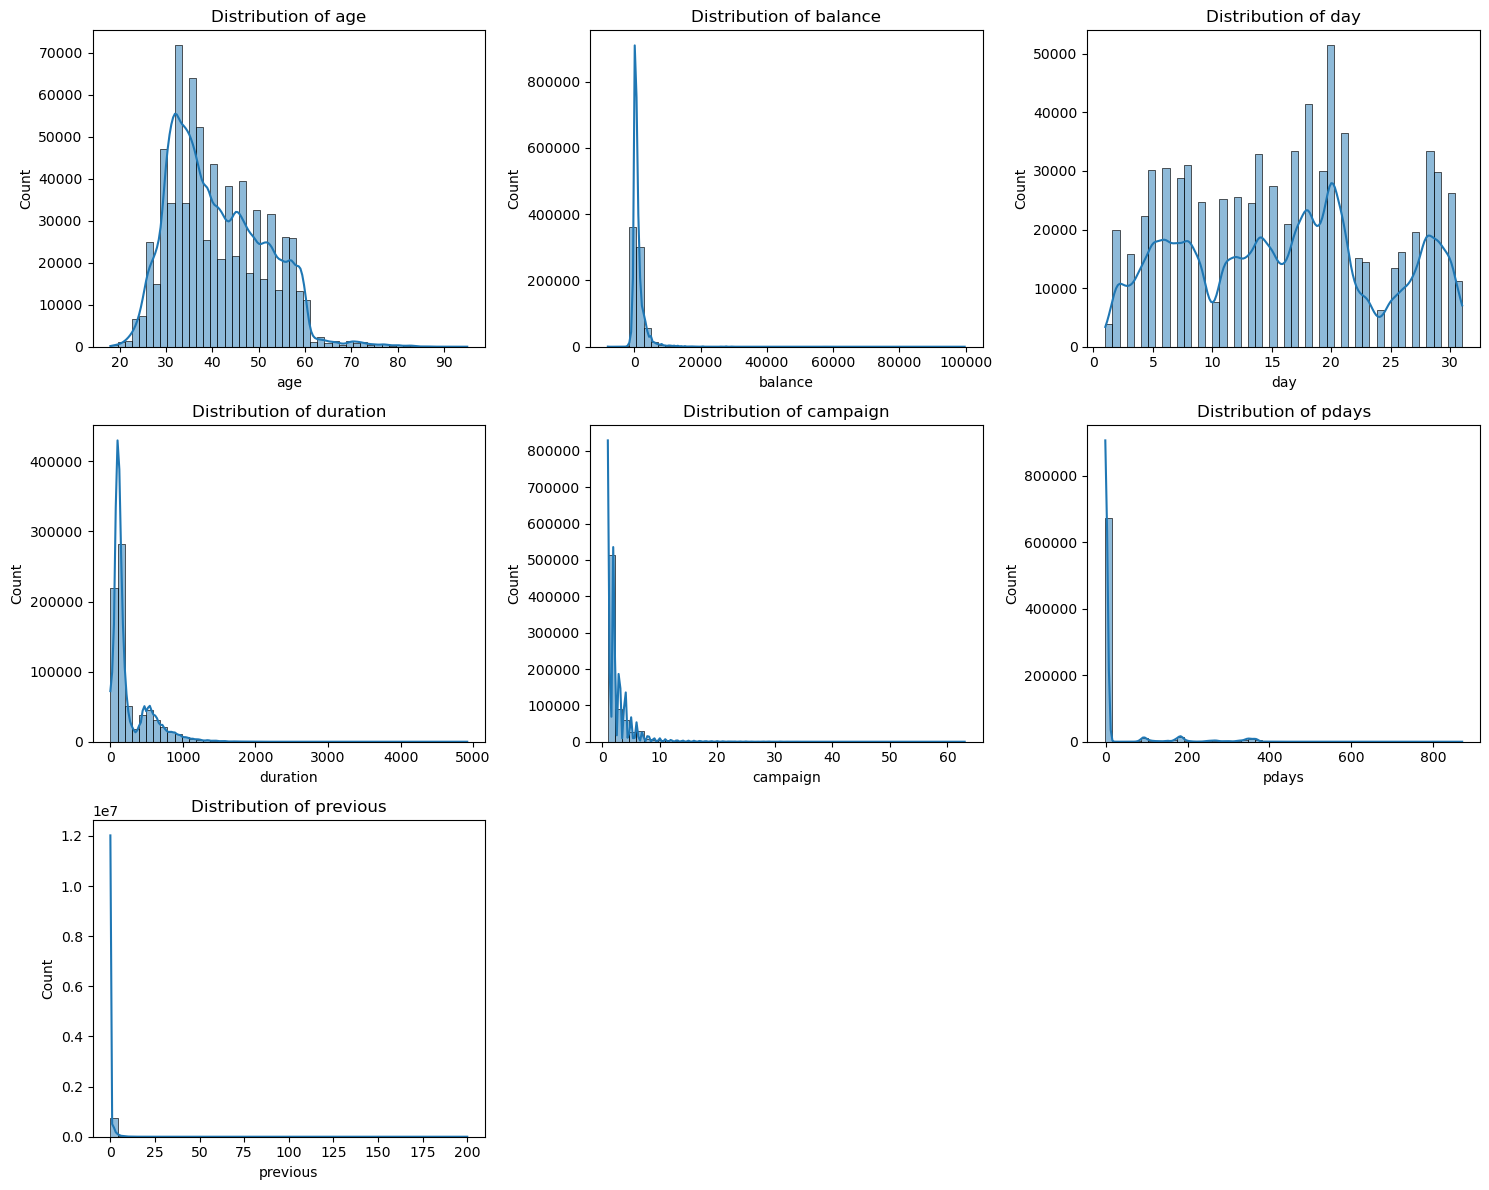

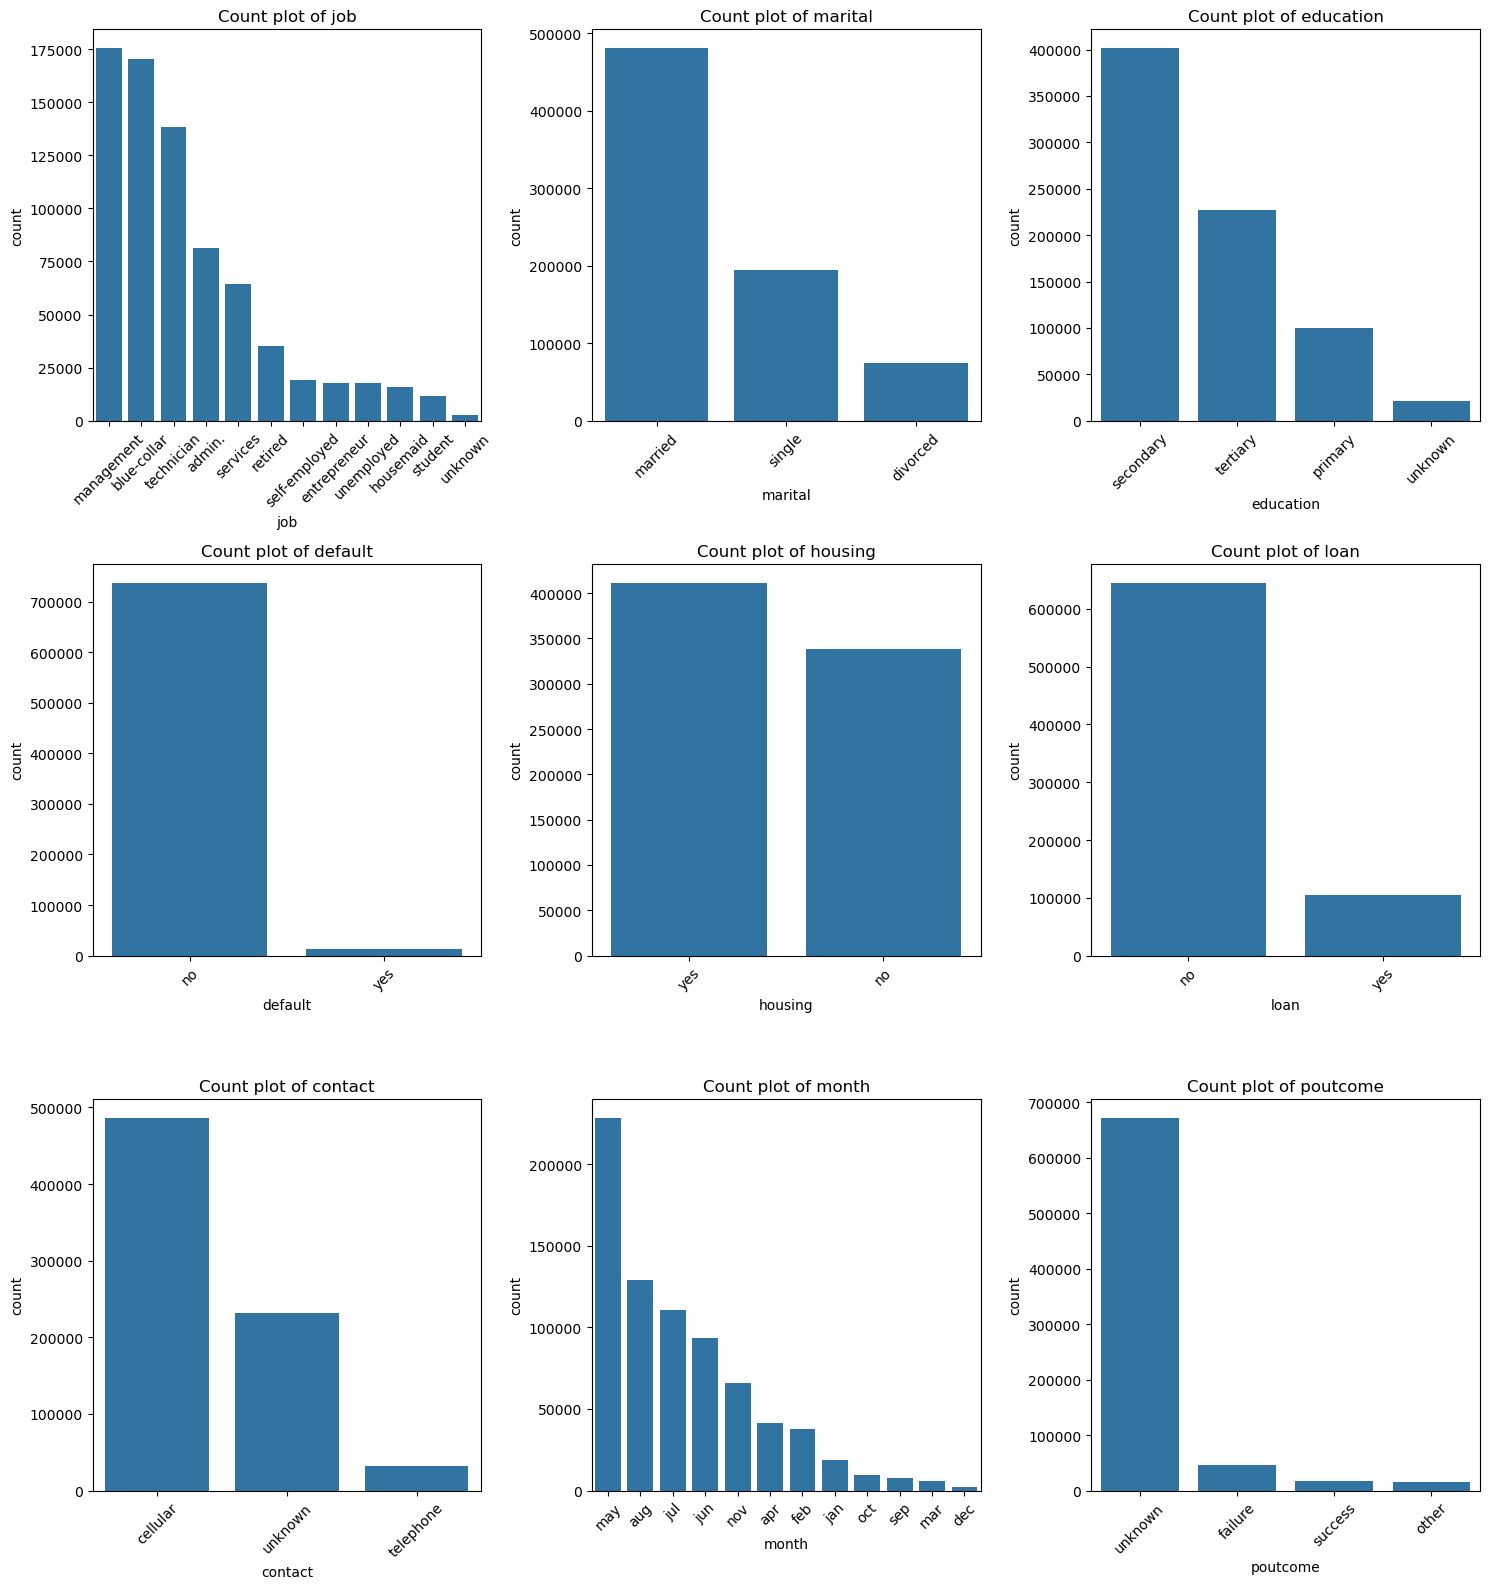

y
0    659512
1     90488
Name: count, dtype: int64


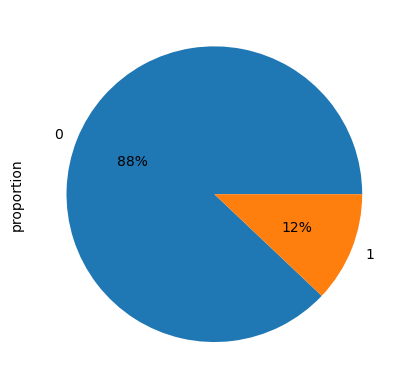

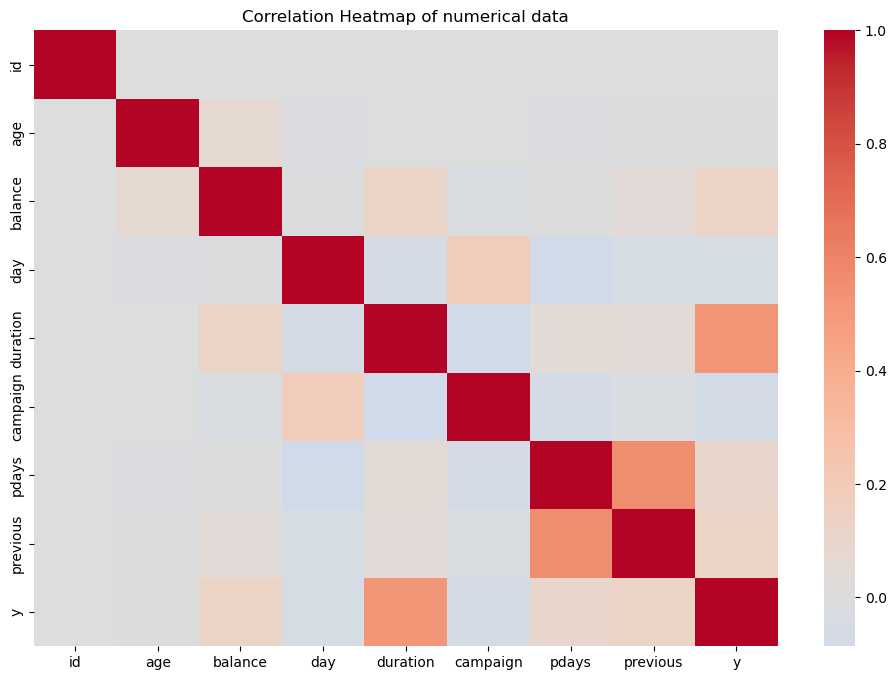

In [7]:
# Distribution of numerical data
num_col.remove('id')
num_col.remove('y')
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_col, start=1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Categorical feature analysis
plt.figure(figsize=(15, 16))
for i, col in enumerate(cat_col, start=1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count plot of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Verify the unbalanced of classes with value_counts()
print(df['y'].value_counts())
df['y'].value_counts(normalize=True).plot(kind='pie', autopct='%.0f%%')

# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of numerical data")
plt.show()

## Exploratory Data Analysis (EDA):
### Numerical data analysis

- **Age**: Most clients age fall between 33 and 48 years old. The minimum age is 18 and the oldest is 95 years old.
- **Balance**: The average balance is 1.2k and the hist shows a positive skewness. Most of the data is centralized around zero however, there are a few outliers near 100k.
- **Day**: There's no outstanding skew, it looks like a uniform distribution accross all days of the month.
- **Duration**: Hist shows a positive skewness. Most of the calls lasted less than ~360 seconds however, there were calls that had a duration up to several thousand seconds.
- **Campaign**: Most of the clients were contacted less than 3 times however, there are extreme cases (>50).
- **Previous**: Majority of the clients had zero previous contacts.

### Categorical  data analysis
- **Job**: The three most repeated jobs are management, blue-collar and technician. The rarest jobs are unknown, student and housemaid.
- **Marital**: Most of the clients are married.
- **Education**: The majority have secondary education.
- **Default**: Almost all are no and just a very few defaults.
- **Housing**: There are few more clients with a housing loan.
- **Loan**: Vast majority don't have a loan.
- **Contact**: The prefer contact is cellular.
- **Poutcome**: Largely unknown with very few success and failures.

### Balance of classes
- There's an outstanding imbalance between 0 (No suscription) and 1 (suscription) hence, the usage of class_weight or other methods will be very important here.

### Correlation of numerical data
- We can observe that there is a strong correlation between duration and the target.
- Most of the variables show a weak correlation against the target.
- There's also, a strong correlation between pdays and previous.

## Data processing

In [8]:
# Separate features and target
X = df.drop(columns=['id', 'y'], axis=1)
y = df['y']

X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown
1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown
2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown
3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown
4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown


In [9]:
# Select numerical and categorical columns and save them
num_col = [c for c in X.columns if X[c].dtype in ['int64', 'float64']]
cat_col = X.select_dtypes(include='object').columns

# Scale numerical features
scaler = StandardScaler()
X[num_col] = scaler.fit_transform(X[num_col])

#Encode categorical features
le = LabelEncoder()
for col in cat_col:
    X[col] = le.fit_transform(X[col])

# Split data into train and validation data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=12345)

print(f"Train set shape: {X_train.shape}")
print(f"Validation set shape: {X_valid.shape}")

Train set shape: (562500, 16)
Validation set shape: (187500, 16)


In [14]:
# LogisticRegression model
LR_model = LogisticRegression(
    solver='liblinear',
    class_weight='balanced', 
    max_iter=2000, 
    random_state=12345
)

LR_model.fit(X_train, y_train)
predictions_valid_log = LR_model.predict_proba(X_valid)[:, 1]
auc_log = roc_auc_score(y_valid, predictions_valid_log)

# RandomForestClassifier model
RFC_model = RandomForestClassifier(
    random_state=12345, 
    class_weight='balanced',
    n_estimators=200,
    n_jobs=-1
)

RFC_model.fit(X_train, y_train)
predictions_valid_forest = RFC_model.predict_proba(X_valid)[:, 1]
auc_forest = roc_auc_score(y_valid, predictions_valid_forest)

# XGBClassifier model
XGBC_model = XGBClassifier(
    scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1]),
    eval_metric='auc',
    random_state=12345
)

XGBC_model.fit(X_train, y_train)
predictions_valid_xgbc = XGBC_model.predict_proba(X_valid)[:, 1]
auc_xgbc = roc_auc_score(y_valid, predictions_valid_xgbc)

# LightGBMClassifier model
LGBMC_model = LGBMClassifier(
    class_weight='balanced',
    random_state=12345,
    n_estimators=200
)

LGBMC_model.fit(X_train, y_train)
predictions_valid_lgbmc = LGBMC_model.predict_proba(X_valid)[:, 1]
auc_lgmc = roc_auc_score(y_valid, predictions_valid_lgbmc)

[LightGBM] [Info] Number of positive: 68048, number of negative: 494452
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 998
[LightGBM] [Info] Number of data points in the train set: 562500, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [15]:
# Compare results
print("ROC AUC Scores:")
print("LogisticRegression model: ", auc_log)
print("RandomForestClassifier model: ", auc_forest)
print("XGBClassifier model: ", auc_xgbc)
print("LightGBMClassifier model: ", auc_lgmc)

ROC AUC Scores:
LogisticRegression model:  0.9210675448759194
RandomForestClassifier model:  0.9630815732106706
XGBClassifier model:  0.9656935887355174
LightGBMClassifier model:  0.9663558920561053


### Data processing

- Logistic Regression model performs really well (0.92 AUC) but, non-linear models have a clearly better performance!
- Random Forest Classifier model shows a better performance compared to Logistic Regression model as we can see (0.96 AUC)
- XGBClassifier and LightGBMClassifier models had the best performance than LR and RFC models, LightGBM model hass a slight better performance than XGBoost model, (0.97 AUC)

## Test data submissions

In [16]:
# Training final model and getting the test validations to submit
df_test.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


In [18]:
# Separate features and target
X_test = df_test.drop(columns=['id'], axis=1)

X_test.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


In [19]:
# Select numerical and categorical columns and save them
num_col = [c for c in X_test.columns if X_test[c].dtype in ['int64', 'float64']]
cat_col = X_test.select_dtypes(include='object').columns

# Scale numerical features
scaler = StandardScaler()
X_test[num_col] = scaler.fit_transform(X_test[num_col])

#Encode categorical features
le = LabelEncoder()
for col in cat_col:
    X_test[col] = le.fit_transform(X_test[col])

In [20]:
LGBMC_model.fit(X, y)
predictions_test = LGBMC_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id' : df_test['id'],
    'y' : predictions_test
})

submission.to_csv('submission.csv', index=False)

print("Submission preview:")
submission.head()

[LightGBM] [Info] Number of positive: 90488, number of negative: 659512
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011893 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 997
[LightGBM] [Info] Number of data points in the train set: 750000, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Submission preview:


,id,y
0,750000,0.028250
1,750001,0.757748
2,750002,0.001864
3,750003,0.000955
4,750004,0.113604
